# N08 — TCN Sequence Length Configuration

**Purpose:** Determine the optimal TCN input sequence length (window size) for the global model
and for each per-compound fine-tuned model, based on the empirical stint length distributions
in `laps_tiredeg.parquet`.

**Why a separate notebook:**
The sequence length is a critical architectural hyperparameter that directly affects model capacity,
padding overhead, and training efficiency. Determining it analytically — rather than hardcoding a
guess — ensures the TCN receptive field is calibrated to real stint data. Exporting the result as
a JSON config keeps N09 (model training) free of analysis code.

**Execution order:** N07 → **N08** → N09

**Output:** `data/processed/tiredeg_sequence_config.json`

**Contents:**
1. Load `laps_tiredeg.parquet` (N07 Step 8 output)
2. Global stint length distribution → global window size
3. Per-compound stint length distributions → per-compound window sizes
4. Padding overhead analysis (truncation rate vs padding waste trade-off)
5. Manual review & window size decisions (with override support)
6. Export sequence config JSON

## Step 0 — Imports & Paths

In [15]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

# ── Paths ─────────────────────────────────────────────────────────────────────
repo_root      = Path.cwd()
while not (repo_root / '.git').exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

processed_path = repo_root / 'data' / 'processed'
outputs_path   = Path.cwd() / 'outputs'
outputs_path.mkdir(parents=True, exist_ok=True)

print(f'Repo root : {repo_root}')
print(f'Outputs   : {outputs_path}')

Repo root : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
Outputs   : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\tire_degradation\outputs


## Step 1 — Load Data

In [16]:
def load_tiredeg(processed_path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load laps_tiredeg and compute one row per stint (max TyreLife = stint length)."""
    df = pd.read_parquet(processed_path / 'laps_tiredeg.parquet')

    # Keep only dry compounds with a resolved absolute compound
    dry = df[
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
        df['AbsoluteCompound'].notna()
    ].copy()

    GROUP = ['Year', 'GP_Name', 'DriverNumber', 'Stint']

    stints = (
        dry.groupby(GROUP)
        .agg(
            stint_length=('TyreLife', 'max'),
            AbsoluteCompound=('AbsoluteCompound', 'first'),
        )
        .reset_index()
    )

    print(f'Dry laps : {len(dry):,}')
    print(f'Stints   : {len(stints):,}')
    print(f'Compounds: {sorted(stints["AbsoluteCompound"].unique())}')
    return dry, stints


dry, stints = load_tiredeg(processed_path)

Dry laps : 64,271
Stints   : 3,222
Compounds: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']


## Step 2 — Global Stint Length Distribution

The global model is trained on all dry compounds pooled. Its window size should cover the
vast majority of stints without requiring excessive padding for shorter ones.

The **CDF (Cumulative Distribution Function)** shows, for each stint length X, what fraction
of stints are X laps or shorter. It answers directly: *"if I set window size = W, what
percentage of stints fit without truncation?"* — which is exactly the question we need here.

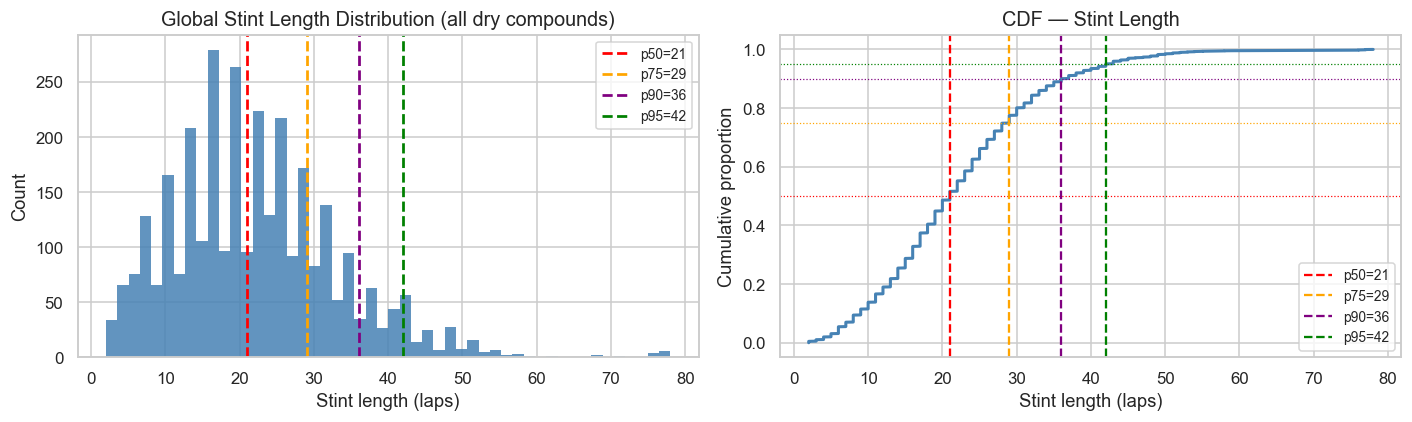

── Global stint length percentiles ──
   p50 =  21 laps  |  covers 51.6% of stints  | truncates 48.4%
   p75 =  29 laps  |  covers 77.5% of stints  | truncates 22.5%
   p90 =  36 laps  |  covers 90.0% of stints  | truncates 10.0%
   p95 =  42 laps  |  covers 95.1% of stints  | truncates 4.9%
   p99 =  52 laps  |  covers 99.0% of stints  | truncates 1.0%

→ Recommended global window_size: 36 laps (p90)


In [17]:
def analyse_global_distribution(stints: pd.DataFrame, outputs_path: Path) -> dict:
    """Compute percentiles for the global (all compounds) stint length distribution."""
    lengths = stints['stint_length'].dropna()
    pcts = [50, 75, 90, 95, 99]
    quantiles = {f'p{p}': int(np.percentile(lengths, p)) for p in pcts}

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histogram
    axes[0].hist(lengths, bins=50, edgecolor='none', alpha=0.85, color='steelblue')
    colors = {'p50': 'red', 'p75': 'orange', 'p90': 'purple', 'p95': 'green'}
    for label, val in quantiles.items():
        if label in colors:
            axes[0].axvline(val, color=colors[label], linestyle='--',
                            linewidth=1.8, label=f'{label}={val}')
    axes[0].set_title('Global Stint Length Distribution (all dry compounds)')
    axes[0].set_xlabel('Stint length (laps)')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=9)

    # Cumulative distribution
    sorted_len = np.sort(lengths)
    cdf = np.arange(1, len(sorted_len) + 1) / len(sorted_len)
    axes[1].plot(sorted_len, cdf, linewidth=2, color='steelblue')
    for label, val in quantiles.items():
        if label in colors:
            pval = int(label[1:]) / 100
            axes[1].axvline(val, color=colors[label], linestyle='--',
                            linewidth=1.5, label=f'{label}={val}')
            axes[1].axhline(pval, color=colors[label], linestyle=':', linewidth=0.8)
    axes[1].set_title('CDF — Stint Length')
    axes[1].set_xlabel('Stint length (laps)')
    axes[1].set_ylabel('Cumulative proportion')
    axes[1].legend(fontsize=9)

    fig.tight_layout()
    fig.savefig(outputs_path / 'global_stint_length.png', bbox_inches='tight')
    plt.show()

    print('── Global stint length percentiles ──')
    for k, v in quantiles.items():
        pct_covered = (lengths <= v).mean()
        pct_truncated = (lengths > v).mean()
        print(f'  {k:>4} = {v:>3} laps  |  covers {pct_covered:.1%} of stints  '
              f'| truncates {pct_truncated:.1%}')

    recommended = quantiles['p90']
    print(f'\n→ Recommended global window_size: {recommended} laps (p90)')
    return quantiles


global_quantiles = analyse_global_distribution(stints, outputs_path)

### Step 2 — Observations

- Distribution is **bimodal**: first peak at 17–20 laps (aggressive 2-stop strategies), second at 21–25 laps (standard 1-stop). The CDF confirms the step-like shape — stints cluster at discrete strategy lengths rather than spreading uniformly.
- **p90 = 36 laps confirmed** as global window size. Going to p95 = 42 gains only 5 pp of coverage at the cost of 6 extra padding positions for every short stint — not worth it given median = 21 laps.
- The long tail beyond lap 42 corresponds to Monaco-style one-stoppers and late safety-car extended stints. These are truncated to the last 36 laps;  ensures the model still knows the tire age at every truncated position.
- **Selected:** — consistent with N07 Step 4 analysis.

## Step 3 — Per-Compound Stint Length Analysis

Each per-compound fine-tuned model can use a different window size calibrated to its own
stint length distribution. Harder compounds (C1, C2) tend to run longer stints; softer
compounds (C4, C5) are pitted earlier.

── Per-compound stint length statistics ──
          n_stints  mean  p50  p75  p90  p95  p99  window_size
compound                                                      
C1             285  21.9   21   27   31   39   48           31
C2             550  23.8   23   31   40   44   51           40
C3            1339  23.1   22   30   38   43   53           38
C4             859  20.9   19   27   34   38   54           34
C5             183  17.5   15   25   31   35   48           31
C6               4  14.5    9   16   25   28   31           25


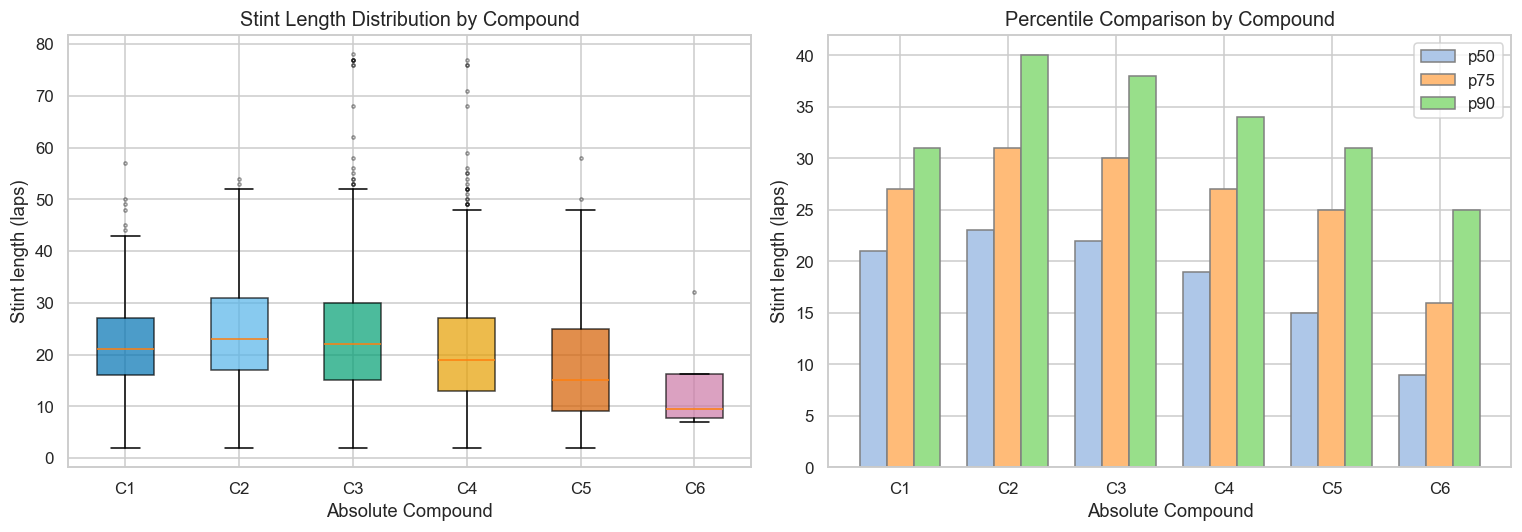

In [18]:
def analyse_per_compound(stints: pd.DataFrame, outputs_path: Path) -> pd.DataFrame:
    """Compute percentiles and recommend window_size per absolute compound."""
    compounds = sorted(stints['AbsoluteCompound'].dropna().unique())
    pcts = [50, 75, 90, 95, 99]

    rows = []
    for c in compounds:
        grp = stints[stints['AbsoluteCompound'] == c]['stint_length'].dropna()
        row = {'compound': c, 'n_stints': len(grp), 'mean': round(grp.mean(), 1)}
        for p in pcts:
            row[f'p{p}'] = int(np.percentile(grp, p))
        row['window_size'] = row['p90']   # default recommendation
        rows.append(row)

    stats = pd.DataFrame(rows).set_index('compound')

    print('── Per-compound stint length statistics ──')
    print(stats.to_string())

    # ── Visualisation ──────────────────────────────────────────────────────────
    palette = {'C1': '#0072B2', 'C2': '#56B4E9', 'C3': '#009E73',
               'C4': '#E69F00', 'C5': '#D55E00', 'C6': '#CC79A7'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Box plots per compound
    data_for_box = [
        stints[stints['AbsoluteCompound'] == c]['stint_length'].dropna().values
        for c in compounds
    ]
    bp = axes[0].boxplot(data_for_box, patch_artist=True, showfliers=True,
                         flierprops={'markersize': 2, 'alpha': 0.4})
    for patch, c in zip(bp['boxes'], compounds):
        patch.set_facecolor(palette.get(c, 'grey'))
        patch.set_alpha(0.7)
    axes[0].set_xticklabels(compounds)
    axes[0].set_title('Stint Length Distribution by Compound')
    axes[0].set_xlabel('Absolute Compound')
    axes[0].set_ylabel('Stint length (laps)')

    # Percentile bar chart (p50 / p75 / p90 per compound)
    x = np.arange(len(compounds))
    width = 0.25
    for i, (pct, color) in enumerate([(50, '#aec7e8'), (75, '#ffbb78'), (90, '#98df8a')]):
        vals = [stats.loc[c, f'p{pct}'] if c in stats.index else 0 for c in compounds]
        axes[1].bar(x + i * width, vals, width, label=f'p{pct}', color=color, edgecolor='grey')
    axes[1].set_xticks(x + width)
    axes[1].set_xticklabels(compounds)
    axes[1].set_title('Percentile Comparison by Compound')
    axes[1].set_xlabel('Absolute Compound')
    axes[1].set_ylabel('Stint length (laps)')
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(outputs_path / 'compound_stint_percentiles.png', bbox_inches='tight')
    plt.show()

    return stats


compound_stats = analyse_per_compound(stints, outputs_path)

### Step 3 — Observations

- **C2 has the longest stints (p90=40)**, not C1 as one might expect from the hardest compound. C2 is frequently nominated as HARD at low-stress circuits (Monaco, Jeddah, Baku) where teams run long 1-stop strategies with minimal degradation. C1 by contrast is allocated to demanding circuits (Barcelona, Silverstone, Bahrain) where physical stress forces earlier pit stops — hence C1 p90=31, lower than C2.
- **C5 and C1 share the same p90=31**, for opposite physical reasons: C5 is pitted early because it wears quickly; C1 is pitted earlier than C2/C3 because it runs at the most demanding venues.
- **C4 has the widest spread** (outliers up to p99=54): used as both SOFT (short stints) and MEDIUM/HARD (longer stints) at a variety of circuits, producing a flatter, wider distribution than more specialised compounds.
- **C6: 4 stints only** — statistically meaningless. No dedicated model; falls back to the global model at inference time. Confirmed.
- **Window sizes set to p90 per compound**: C1=31, C2=40, C3=38, C4=34, C5=31. Note that C2 and C3 exceed the global window of 36 — the global model (ablation study) will truncate ~10–15% of their stints, acceptable for a pooled model. Per-compound models use their own window to avoid unnecessary truncation.

#### Important Note
**On window size trade-offs:** a window too large means most sequences are padding — the model trains on mostly empty positions, diluting gradients and increasing memory cost. A window too small means long stints get truncated and the model never sees the late-stint degradation cliff during training. The padding mask mitigates the first problem (padded positions do not contribute to the loss), so the main practical concern at large windows is computational efficiency. The Step 4 analysis below quantifies this trade-off visually per compound.



## Step 4 — Padding Overhead Analysis

For each candidate window size W, two metrics are computed across all stints of each compound:

- **Truncation rate:** fraction of stints longer than W that must be cut. A high truncation rate means the model never sees the full degradation curve for long stints — it misses the late-stint cliff.
- **Mean padding waste:** for stints shorter than W, the fraction of the sequence that is zero-padding. A high padding waste means most of the tensor is empty — more memory used, more masked positions the model has to ignore.

The goal is to find the **knee of both curves simultaneously**: low truncation without excessive padding. The p90 per compound (dotted vertical lines) is the candidate choice; the black dashed line marks the global window=36 used for the ablation study.


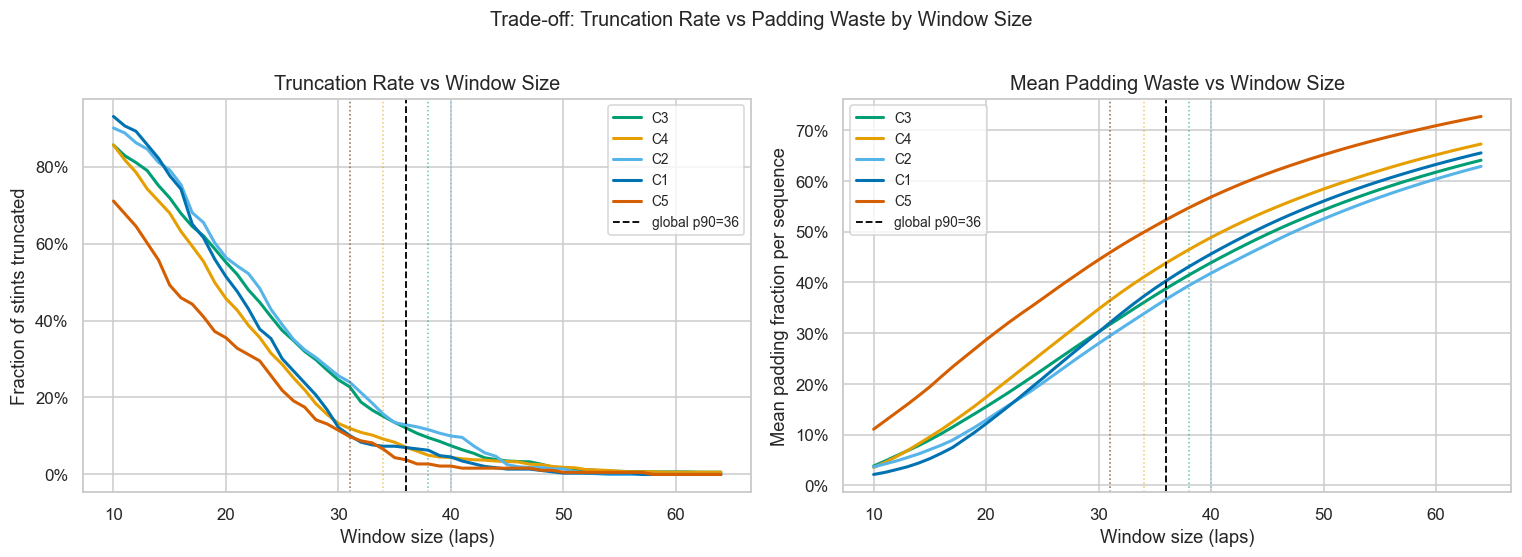

In [19]:
def analyse_padding_overhead(
    stints: pd.DataFrame,
    compound_stats: pd.DataFrame,
    outputs_path: Path,
) -> None:
    """For each compound, plot truncation rate and mean padding fraction vs window size."""
    compounds = sorted(
        stints['AbsoluteCompound'].dropna().unique(),
        key=lambda c: compound_stats.loc[c, 'n_stints'] if c in compound_stats.index else 0,
        reverse=True
    )
    # Limit to C1-C5 (C6 excluded from dedicated models)
    compounds = [c for c in compounds if c != 'C6']

    palette = {'C1': '#0072B2', 'C2': '#56B4E9', 'C3': '#009E73',
               'C4': '#E69F00', 'C5': '#D55E00'}

    window_range = range(10, 65, 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for c in compounds:
        lengths = stints[stints['AbsoluteCompound'] == c]['stint_length'].values
        trunc_rates, pad_wastes = [], []
        for W in window_range:
            trunc = (lengths > W).mean()
            pad_frac = np.where(lengths < W, (W - lengths) / W, 0).mean()
            trunc_rates.append(trunc)
            pad_wastes.append(pad_frac)

        color = palette.get(c, 'grey')
        axes[0].plot(list(window_range), trunc_rates, label=c, color=color, linewidth=2)
        axes[1].plot(list(window_range), pad_wastes, label=c, color=color, linewidth=2)

        # Mark p90 for this compound
        if c in compound_stats.index:
            w90 = compound_stats.loc[c, 'p90']
            axes[0].axvline(w90, color=color, linestyle=':', linewidth=1, alpha=0.6)
            axes[1].axvline(w90, color=color, linestyle=':', linewidth=1, alpha=0.6)

    for ax, title, ylabel in [
        (axes[0], 'Truncation Rate vs Window Size', 'Fraction of stints truncated'),
        (axes[1], 'Mean Padding Waste vs Window Size', 'Mean padding fraction per sequence'),
    ]:
        ax.set_title(title)
        ax.set_xlabel('Window size (laps)')
        ax.set_ylabel(ylabel)
        ax.axvline(36, color='black', linestyle='--', linewidth=1.2,
                   label='global p90=36')
        ax.legend(fontsize=9)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

    fig.suptitle('Trade-off: Truncation Rate vs Padding Waste by Window Size',
                 fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig(outputs_path / 'padding_overhead_analysis.png', bbox_inches='tight')
    plt.show()


analyse_padding_overhead(stints, compound_stats, outputs_path)

### Step 4 — Observations

- **Truncation rate drops sharply before lap 35** for all compounds — most of the benefit of increasing window size is captured before reaching the global p90=36 (black dashed line). Beyond lap 40 the curves are nearly flat, meaning further increases barely reduce truncation.
- **C5 (orange) decays fastest**: truncation drops to ~10% already at window=31, consistent with its short stints. Using window=31 for C5 is well justified.
- **C2 and C1 (light/dark blue) decay slowest**: they still have ~10% truncation at window=36, reaching ~5% only at window=40–42. This confirms the per-compound window sizes (C1=31, C2=40) make more sense than the global 36 for their dedicated models.
- **Padding waste at the chosen p90 values (dotted vertical lines)**: all compounds sit at roughly 35–45% mean padding at their respective p90. C5 is higher (~50%) due to its very short median (15 laps) relative to window=31. This is acceptable given the padding mask.
- **No override needed**: the p90 values from Step 3 sit at the natural knee of both curves — the point where truncation is low and padding has not yet exploded. No manual adjustment required.


## Step 5 — Manual Review & Window Size Decisions

Review the plots and table from Steps 2–4 and confirm or adjust the p90 recommendation
per compound. Adjustment rules:

- If p90 is very close to p95 (< 5 laps difference) → consider rounding down to p90
- If n_stints < 50 → flag the compound; p90 is unreliable with few samples
- C6 → no dedicated model (< 10 stints); always falls back to global

The cell below allows manual overrides before exporting.

In [20]:
def build_sequence_config(
    global_quantiles: dict,
    compound_stats: pd.DataFrame,
    stints: pd.DataFrame,
    manual_overrides: dict | None = None,
) -> dict:
    """
    Build the sequence config dict.

    Parameters
    ----------
    manual_overrides : dict, optional
        Compound-level overrides, e.g. {'C1': 30} to force window_size=30 for C1.
        Use after reviewing plots from Steps 3-4.
    """
    manual_overrides = manual_overrides or {}
    global_window = global_quantiles['p90']

    per_compound = {}
    for c, row in compound_stats.iterrows():
        n = int(row['n_stints'])
        p90 = int(row['p90'])
        window = manual_overrides.get(c, p90)
        status = 'ok'
        if n < 50:
            status = 'low_sample'
        if c == 'C6':
            status = 'no_model_fallback_global'
            window = None

        per_compound[c] = {
            'window_size': window,
            'basis': f'p90' if c not in manual_overrides else 'manual_override',
            'p50': int(row['p50']),
            'p75': int(row['p75']),
            'p90': p90,
            'p95': int(row['p95']),
            'n_stints': n,
            'status': status,
        }

    config = {
        '_comment': 'TCN sequence length config. Generated by N09_tiredeg_sequence_config.ipynb.',
        '_usage': 'Import in N08. Use global.window_size for the global model; '
                  'per_compound[compound].window_size for fine-tuned models. '
                  'C6 has no dedicated model — use global.',
        'global': {
            'window_size': global_window,
            'basis': 'p90_all_dry_compounds',
            'p50': global_quantiles['p50'],
            'p75': global_quantiles['p75'],
            'p90': global_quantiles['p90'],
            'p95': global_quantiles['p95'],
        },
        'per_compound': per_compound,
        'padding_strategy': 'left_zero_pad',
        'truncation_strategy': 'truncate_from_start',
        'masking': True,
        'notes': [
            'window_size = p90 of stint length per compound (or manual override).',
            'Stints shorter than window_size are left-zero-padded; mask=True on padding positions.',
            'Stints longer than window_size are truncated from the start (most recent laps kept).',
            'C6: insufficient stints for a dedicated model; falls back to global at inference time.',
            'Overrides can be applied in N09 Step 5 if analysis justifies a different value.',
        ],
    }
    return config


# ── Manual overrides (edit after reviewing plots) ──────────────────────────────
# Leave empty {} to use p90 for all compounds, or add entries like {'C2': 38}
MANUAL_OVERRIDES = {}

config = build_sequence_config(global_quantiles, compound_stats, stints, MANUAL_OVERRIDES)

# ── Preview ────────────────────────────────────────────────────────────────────
print('── Sequence config summary ──')
print(f"  Global window_size : {config['global']['window_size']} laps")
print()
print(f"  {'Compound':<10} {'window_size':>12} {'n_stints':>10} {'status':<20}")
for c, v in config['per_compound'].items():
    ws = str(v['window_size']) if v['window_size'] is not None else 'None (global)'
    print(f"  {c:<10} {ws:>12} {v['n_stints']:>10} {v['status']:<20}")

── Sequence config summary ──
  Global window_size : 36 laps

  Compound    window_size   n_stints status              
  C1                   31        285 ok                  
  C2                   40        550 ok                  
  C3                   38       1339 ok                  
  C4                   34        859 ok                  
  C5                   31        183 ok                  
  C6         None (global)          4 no_model_fallback_global


### Step 5 — Sequence Config Summary

All compounds pass the minimum sample threshold (n ≥ 50) and use their p90 as window size — no manual overrides needed. C6 is flagged as `no_model_fallback_global` with only 4 stints, confirming it will use the global model at inference time.

| Compound | window_size | basis |
|----------|-------------|-------|
| Global | 36 | p90 all dry compounds |
| C1 | 31 | p90 |
| C2 | 40 | p90 |
| C3 | 38 | p90 |
| C4 | 34 | p90 |
| C5 | 31 | p90 |
| C6 | — (global) | insufficient data |


## Step 6 — Export Sequence Config JSON

In [21]:
def export_sequence_config(config: dict, processed_path: Path) -> None:
    """Save the sequence config to JSON for import in N08."""
    out_path = processed_path / 'tiredeg_sequence_config.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(config, f, indent=2)
    print(f'Saved → {out_path}')
    print(f'Keys  : {list(config.keys())}')


export_sequence_config(config, processed_path)

Saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\tiredeg_sequence_config.json
Keys  : ['_comment', '_usage', 'global', 'per_compound', 'padding_strategy', 'truncation_strategy', 'masking', 'notes']


Config exported to `data/processed/tiredeg_sequence_config.json` and ready for import in N09.